# Calculations vs Decisions in Security

Most security work produces calculations, not decisions. A risk register entry, a vulnerability scan report, a Monte Carlo estimate — none of these are decisions until someone irrevocably allocates resources based on them. This notebook explores the distinction and why it matters for how we structure security analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from decision_security.synth import make_rng, sample
from decision_security.montecarlo import simulate_aggregate_losses, make_lognormal_severity

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"

## 1. The Calculation-Decision Boundary

A calculation is revocable — you can change your mind without committing resources. A decision is irrevocable — budget is spent, people are hired, contracts are signed. Most "risk-based decisions" in security are actually calculations dressed up as decisions: the risk register was updated, but nothing changed.

In [2]:
activities = pd.DataFrame([
    {"activity": "Run a vulnerability scan", "type": "Calculation", "why": "No resources committed; you can ignore the results"},
    {"activity": "Buy and deploy EDR ($200K)", "type": "Decision", "why": "Budget irrevocably allocated"},
    {"activity": "Estimate annual loss expectancy", "type": "Calculation", "why": "A number on a slide; no action follows automatically"},
    {"activity": "Terminate a vendor relationship", "type": "Decision", "why": "Switching costs are real and immediate"},
    {"activity": "Update the risk register to 'High'", "type": "Calculation", "why": "The label changed; the exposure didn't"},
    {"activity": "Accept residual risk (signed by CISO)", "type": "Decision", "why": "Accountability is assigned; resources are NOT allocated to mitigate"},
])
print(activities.to_string(index=False))

                             activity        type                                                                 why
             Run a vulnerability scan Calculation                  No resources committed; you can ignore the results
           Buy and deploy EDR ($200K)    Decision                                        Budget irrevocably allocated
      Estimate annual loss expectancy Calculation                A number on a slide; no action follows automatically
      Terminate a vendor relationship    Decision                              Switching costs are real and immediate
   Update the risk register to 'High' Calculation                              The label changed; the exposure didn't
Accept residual risk (signed by CISO)    Decision Accountability is assigned; resources are NOT allocated to mitigate


## 2. Decision Quality vs Outcome Quality

Good decisions can produce bad outcomes (you deployed MFA and still got breached). Bad decisions can produce good outcomes (you ignored the audit findings and nothing happened — this time). Evaluating decisions by their outcomes is called "resulting" (Annie Duke). The right question is: given what you knew at the time, was the process sound?

In [3]:
n_trials = 1000

breach_prob = 0.15
breach_cost = 2_000_000
control_cost = 80_000
control_reduction = 0.70

ev_deploy = control_cost + breach_prob * (1 - control_reduction) * breach_cost
ev_skip = breach_prob * breach_cost

good_process_costs = np.where(
    rng.random(n_trials) < breach_prob * (1 - control_reduction),
    control_cost + breach_cost,
    control_cost
)

gut_feel_costs = np.where(
    rng.random(n_trials) < breach_prob,
    breach_cost,
    0
)

gut_wins = np.sum(gut_feel_costs < good_process_costs)
print(f"EV(deploy control): ${ev_deploy:,.0f}")
print(f"EV(skip control):   ${ev_skip:,.0f}")
print(f"Good process is cheaper in EV by ${ev_skip - ev_deploy:,.0f}/year")
print(f"But gut feel 'wins' on {gut_wins}/{n_trials} individual trials ({100*gut_wins/n_trials:.0f}%)")
print(f"Cumulative after {n_trials} trials:")
print(f"  Good process total: ${good_process_costs.sum():,.0f}")
print(f"  Gut feel total:     ${gut_feel_costs.sum():,.0f}")

EV(deploy control): $170,000
EV(skip control):   $300,000
Good process is cheaper in EV by $130,000/year
But gut feel 'wins' on 880/1000 individual trials (88%)
Cumulative after 1000 trials:
  Good process total: $174,000,000
  Gut feel total:     $262,000,000


## 3. Cumulative Advantage of Good Process

On any single trial, gut feel often "wins" — the control cost is paid upfront while the breach
probability is low enough that skipping the control frequently works out. This is why
anecdotal reasoning ("we didn't deploy X and nothing happened") is so persuasive.

But decisions compound. Over hundreds of trials, the EV-optimal strategy pulls ahead
decisively. The chart below shows cumulative costs for both approaches. The gut-feel line
is cheaper in most individual periods but accumulates catastrophic spikes that the
good-process line avoids.

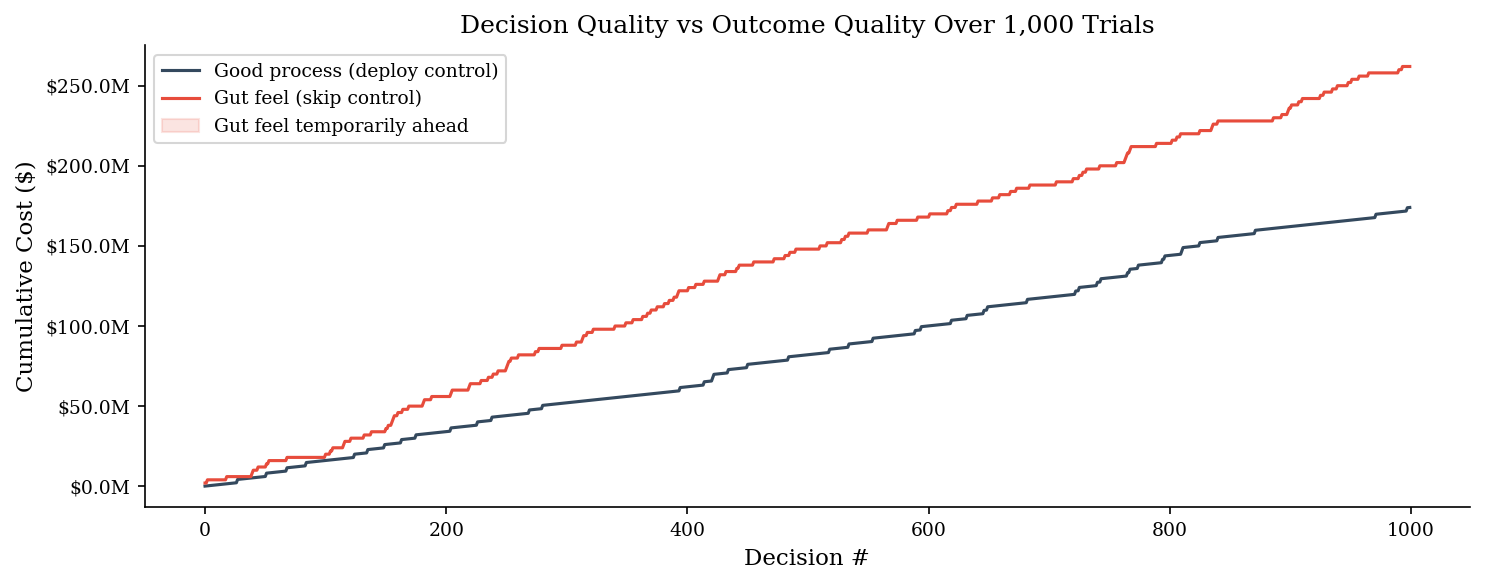

In [4]:
cum_good = np.cumsum(good_process_costs)
cum_gut = np.cumsum(gut_feel_costs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cum_good, color=DARK_BG, linewidth=1.5, label="Good process (deploy control)")
ax.plot(cum_gut, color=ACCENT, linewidth=1.5, label="Gut feel (skip control)")
ax.fill_between(range(n_trials), cum_good, cum_gut,
                where=cum_gut < cum_good, alpha=0.15, color=ACCENT,
                label="Gut feel temporarily ahead")
ax.set_xlabel("Decision #")
ax.set_ylabel("Cumulative Cost ($)")
ax.set_title("Decision Quality vs Outcome Quality Over 1,000 Trials")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

## 4. Anxiety Reduction vs Decision Quality

"Many people don't really care about making better bets. They care about reducing anxiety about their bets." The hidden optimization function in many security decisions is not minimizing expected loss — it's minimizing the discomfort of uncertainty. This leads to over-investing in visible controls (firewalls, antivirus) and under-investing in invisible ones (configuration management, access reviews).

In [5]:
controls = pd.DataFrame([
    {"control": "Next-gen firewall", "cost": 150_000, "risk_reduction": 30_000, "visibility": "High"},
    {"control": "EDR platform", "cost": 200_000, "risk_reduction": 120_000, "visibility": "High"},
    {"control": "Config management", "cost": 50_000, "risk_reduction": 95_000, "visibility": "Low"},
    {"control": "Access review automation", "cost": 40_000, "risk_reduction": 70_000, "visibility": "Low"},
    {"control": "Security awareness training", "cost": 30_000, "risk_reduction": 15_000, "visibility": "High"},
    {"control": "Network segmentation", "cost": 80_000, "risk_reduction": 85_000, "visibility": "Low"},
])
controls["roi"] = controls["risk_reduction"] / controls["cost"]

budget = 300_000

# EV-optimal: pick highest ROI controls first
ev_sorted = controls.sort_values("roi", ascending=False)
ev_portfolio = []
spent = 0
for _, row in ev_sorted.iterrows():
    if spent + row["cost"] <= budget:
        ev_portfolio.append(row["control"])
        spent += row["cost"]

# Anxiety-driven: pick high-visibility, expensive controls first
anxiety_sorted = controls.sort_values("visibility", ascending=False).sort_values("cost", ascending=False)
anx_portfolio = []
spent = 0
for _, row in anxiety_sorted.iterrows():
    if spent + row["cost"] <= budget:
        anx_portfolio.append(row["control"])
        spent += row["cost"]

print("=== EV-Optimal Portfolio ===")
ev_sub = controls[controls["control"].isin(ev_portfolio)]
print(f"Controls: {ev_portfolio}")
print(f"Total cost: ${ev_sub['cost'].sum():,}")
print(f"Total risk reduction: ${ev_sub['risk_reduction'].sum():,}")

print(f"\n=== Anxiety-Driven Portfolio ===")
anx_sub = controls[controls["control"].isin(anx_portfolio)]
print(f"Controls: {anx_portfolio}")
print(f"Total cost: ${anx_sub['cost'].sum():,}")
print(f"Total risk reduction: ${anx_sub['risk_reduction'].sum():,}")

print(f"\nDifference: ${ev_sub['risk_reduction'].sum() - anx_sub['risk_reduction'].sum():,} in lost risk reduction")

=== EV-Optimal Portfolio ===
Controls: ['Config management', 'Access review automation', 'Network segmentation', 'Security awareness training']
Total cost: $200,000
Total risk reduction: $265,000

=== Anxiety-Driven Portfolio ===
Controls: ['EDR platform', 'Network segmentation']
Total cost: $280,000
Total risk reduction: $205,000

Difference: $60,000 in lost risk reduction


## 5. Visualization: ROI by Visibility

The pattern is consistent: high-visibility controls (firewalls, EDR, training) are the
ones that appear in board decks and vendor pitches. Low-visibility controls (config
management, access reviews, segmentation) require operational discipline and produce
no screenshots for the quarterly report.

Yet ROI tells a different story. The unglamorous controls often deliver more risk
reduction per dollar. When the portfolio selection is driven by "what can the board
see" rather than "what reduces risk most efficiently," the organization pays a
measurable premium for comfort.

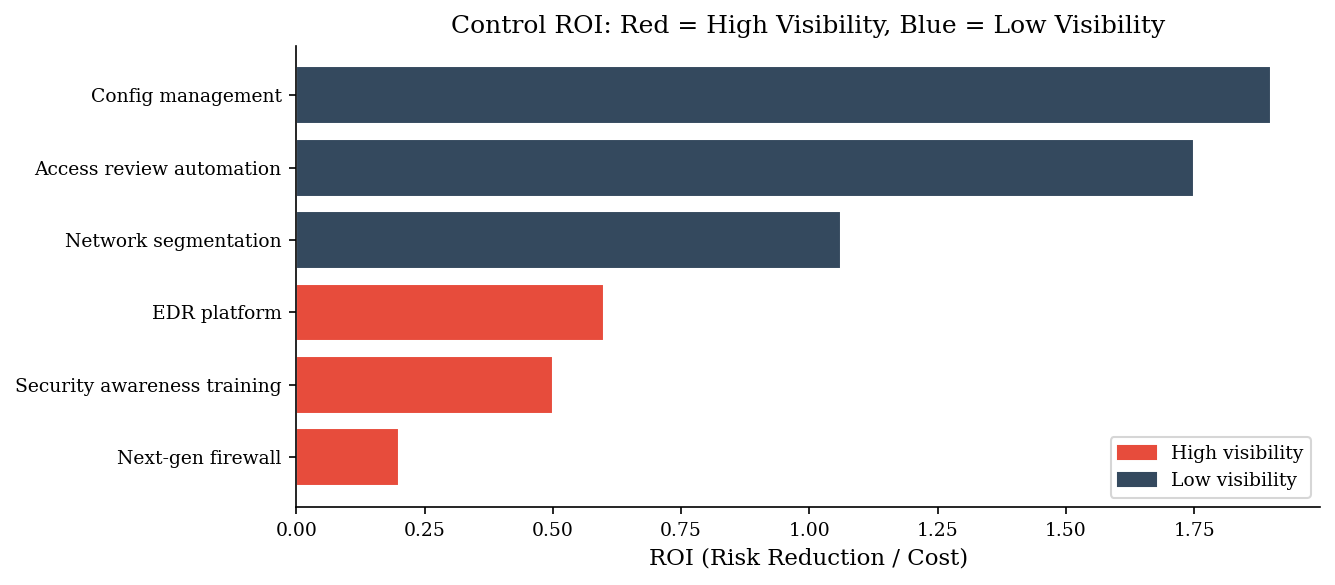

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
colors_map = {"High": ACCENT, "Low": DARK_BG}
bar_colors = [colors_map[v] for v in controls["visibility"]]
order = controls.sort_values("roi", ascending=True).index

ax.barh([controls.loc[i, "control"] for i in order],
        [controls.loc[i, "roi"] for i in order],
        color=[bar_colors[i] for i in order],
        edgecolor="white")
ax.set_xlabel("ROI (Risk Reduction / Cost)")
ax.set_title("Control ROI: Red = High Visibility, Blue = Low Visibility")

high_patch = mpatches.Patch(color=ACCENT, label="High visibility")
low_patch = mpatches.Patch(color=DARK_BG, label="Low visibility")
ax.legend(handles=[high_patch, low_patch])
plt.tight_layout()
plt.show()

## 6. Pitfalls

- **"We did a risk assessment" is not a decision.** Until resources move, nothing happened. Track decisions (what was deployed, decommissioned, or accepted), not assessments produced.
- **Resulting is everywhere in security.** "We got breached therefore our security was bad" ignores that good process reduces probability, not eliminates it. Judge the process, not the single outcome.
- **Anxiety-driven portfolios are expensive.** Visible controls feel better but often have worse ROI than unglamorous operational improvements. If your portfolio is all "things the board can see," question whether you optimized for risk reduction or for comfort.
- **The do-nothing baseline is a decision too.** Choosing not to act is an irrevocable allocation — of risk acceptance. Make it explicit.